# Brain Tumor Detection using Mask R-CNN 

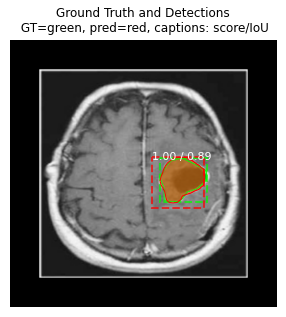

# 1-Import Libraries

In [1]:
pip install -U scikit-image==0.16.2

     |████████████████████████████████| 26.5 MB 10.4 MB/s 
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.18.1
    Uninstalling scikit-image-0.18.1:
      Successfully uninstalled scikit-image-0.18.1
You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os 
import sys
from tqdm import tqdm
import cv2
import numpy as np
import json
import skimage.draw
import matplotlib
import matplotlib.pyplot as plt
import random
from pathlib import Path
from IPython.display import clear_output

DATASET_DIR = '../input/brain-tumor'
ROOT_DIR = Path('/kaggle/working')
#-------- directory to save logs and trained model----
MODEL_DIR = os.path.join(ROOT_DIR, 'logs')
DEFAULT_LOGS_DIR = 'logs' 

# 2-Installing

## 2.1-Install the previous version of TensorFlow(1.14)

In [3]:
!pip install tensorflow==1.14
import tensorflow as tf
clear_output()

In [4]:
tf.__version__

'1.14.0'

## 2.2 Install Keras version (2.1.5)

In [5]:
!pip install keras==2.1.5
clear_output()

## 2.3 Install pycocotools

In [6]:
!pip install pycocotools
clear_output()

# 3-Download the Model Mask_RCNN 

In [7]:
!git clone https://www.github.com/matterport/Mask_RCNN.git
!rm -rf .git # to prevent an error when the kernel is committed
!rm -rf images assets # to prevent displaying images at the bottom of a kernel
clear_output()

In [8]:
# Root directory of the project
ROOT_DIR = os.path.abspath('Mask_RCNN/')
# Import Mask RCNN
sys.path.append(ROOT_DIR) 
from mrcnn.config import Config
from mrcnn import utils
from mrcnn.model import log
import mrcnn.model as modellib
from mrcnn import visualize

clear_output()

# 4-Import COCO config

In [9]:
sys.path.append(os.path.join(ROOT_DIR, 'samples/coco/'))
import coco

# Local path to trained weights file
COCO_MODEL_PATH = os.path.join(ROOT_DIR, "mask_rcnn_coco.h5")
# Download COCO trained weights from Releases if needed
if not os.path.exists(COCO_MODEL_PATH):
    utils.download_trained_weights(COCO_MODEL_PATH)
plt.rcParams['figure.facecolor'] = 'white'

clear_output()

In [10]:
class TumorConfig(Config):
    NAME = 'Brain_Tumor_Detector'
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1
    NUM_CLASSES = 1 + 1 
    DETECTION_MIN_CONFIDENCE = 0.9    
    STEPS_PER_EPOCH = 80
    LEARNING_RATE = 0.005    
config = TumorConfig()
config.display()


Configurations:
BACKBONE                       resnet101
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        100
DETECTION_MIN_CONFIDENCE       0.9
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  1024
IMAGE_META_SIZE                14
IMAGE_MIN_DIM                  800
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [1024 1024    3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.005
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE         

# 5-Brain Tumor Dataset

In [11]:
class BrainTumorDataset(utils.Dataset):
    def load_brain_scan(self, dataset_dir, subset):
        """Load a subset of the FarmCow dataset.
        dataset_dir: Root directory of the dataset.
        subset: Subset to load: train or val
        """
        # Add classes. We have only one class to add.
        self.add_class("tumor", 1, "tumor")

        # Train or validation dataset?
        assert subset in ["Training", "Validation", 'Test']
        dataset_dir = os.path.join(dataset_dir, subset)

        annotations = json.load(open(os.path.join(dataset_dir,'annotations_'+subset+'.json')))
        annotations = list(annotations.values())  # don't need the dict keys

        # The VIA tool saves images in the JSON even if they don't have any
        # annotations. Skip unannotated images.
        annotations = [a for a in annotations if a['regions']]

        # Add images
        for a in annotations:
            # Get the x, y coordinaets of points of the polygons that make up
            # the outline of each object instance. These are stores in the
            # shape_attributes (see json format above)
            # The if condition is needed to support VIA versions 1.x and 2.x.
            if type(a['regions']) is dict:
                polygons = [r['shape_attributes'] for r in a['regions'].values()]
            else:
                polygons = [r['shape_attributes'] for r in a['regions']]

            # load_mask() needs the image size to convert polygons to masks.
            # Unfortunately, VIA doesn't include it in JSON, so we must read
            # the image. This is only managable since the dataset is tiny.
            image_path = os.path.join(dataset_dir, a['filename'])
            
            image = skimage.io.imread(image_path)
            height, width = image.shape[:2]

            self.add_image(
                "tumor",
                image_id=a['filename'],  # use file name as a unique image id
                path=image_path,
                width=width, 
                height=height,
                polygons=polygons
            )

    def load_mask(self, image_id):
        """Generate instance masks for an image.
       Returns:
        masks: A bool array of shape [height, width, instance count] with
            one mask per instance.
        class_ids: a 1D array of class IDs of the instance masks.
        """
        # If not a farm_cow dataset image, delegate to parent class.
        image_info = self.image_info[image_id]
        if image_info["source"] != "tumor":
            return super(self.__class__, self).load_mask(image_id)

        # Convert polygons to a bitmap mask of shape
        # [height, width, instance_count]
        info = self.image_info[image_id]
        mask = np.zeros([info["height"], info["width"], len(info["polygons"])],
                        dtype=np.uint8)
        for i, p in enumerate(info["polygons"]):
            # Get indexes of pixels inside the polygon and set them to 1
            rr, cc = skimage.draw.polygon(p['all_points_y'], p['all_points_x'])
            mask[rr, cc, i] = 1

        # Return mask, and array of class IDs of each instance. Since we have
        # one class ID only, we return an array of 1s
        return mask.astype(np.bool), np.ones([mask.shape[-1]], dtype=np.int32)

    def image_reference(self, image_id):
        """Return the path of the image."""
        info = self.image_info[image_id]
        if info["source"] == "tumor":
            return info["path"]
        else:
            super(self.__class__, self).image_reference(image_id)

In [12]:
# Training dataset.
dataset_train = BrainTumorDataset()
dataset_train.load_brain_scan(DATASET_DIR, 'Training')
dataset_train.prepare()

# Validation dataset
dataset_val = BrainTumorDataset()
dataset_val.load_brain_scan(DATASET_DIR, 'Validation')
dataset_val.prepare()

dataset_test = BrainTumorDataset()
dataset_test.load_brain_scan(DATASET_DIR, 'Test')
dataset_test.prepare()

# 6-Visualizing Some Samples

../input/brain-tumor/Training/12.jpg


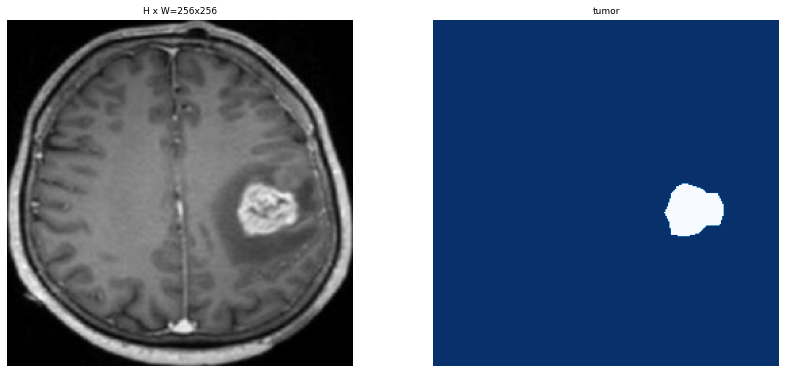

In [13]:
print(dataset_train.image_reference(6))
image = dataset_train.load_image(6)
mask, class_ids = dataset_train.load_mask(6)
visualize.display_top_masks(image, mask, class_ids, dataset_train.class_names, limit=1)
    

../input/brain-tumor/Training/63.jpg


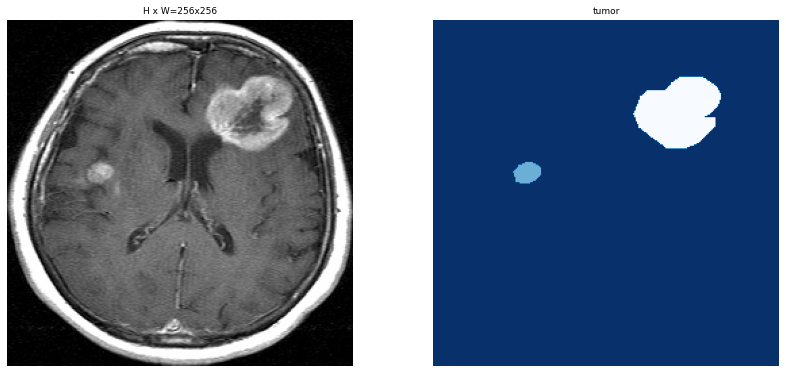

In [14]:
print(dataset_train.image_reference(30))
image = dataset_train.load_image(30)
mask, class_ids = dataset_train.load_mask(30)
visualize.display_top_masks(image, mask, class_ids, dataset_train.class_names, limit=1)

../input/brain-tumor/Training/79.jpg


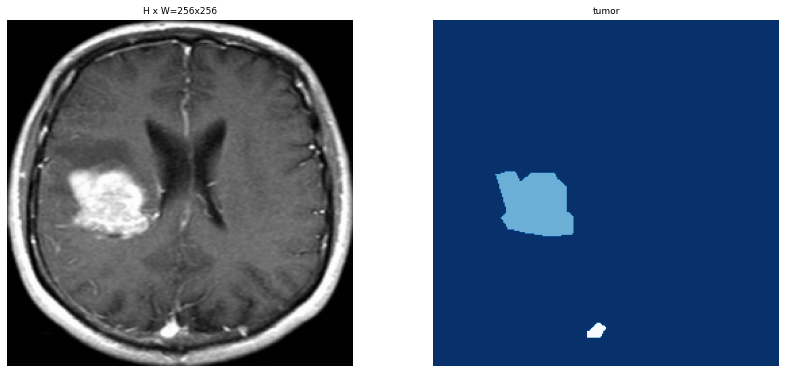

In [15]:
print(dataset_train.image_reference(40))
image = dataset_train.load_image(40)
mask, class_ids = dataset_train.load_mask(40)
visualize.display_top_masks(image, mask, class_ids, dataset_train.class_names, limit=1)

# 7-Build the Mask R-CNN Model Architecture


In [16]:
#-------------- Create model object in training mode------------------------
model = modellib.MaskRCNN(
    mode='training', 
    config=config, 
    model_dir=DEFAULT_LOGS_DIR
)
#-------------- Load weights trained on MS-COCO ---------------------------
model.load_weights(
    COCO_MODEL_PATH, 
    by_name=True, 
    exclude=["mrcnn_class_logits", "mrcnn_bbox_fc", "mrcnn_bbox", "mrcnn_mask"]
)

# 8-Training

In [17]:
model.train(
    dataset_train, dataset_val,
    learning_rate=config.LEARNING_RATE,
    epochs=7,
    layers='heads'
)


Starting at epoch 0. LR=0.005

Checkpoint Path: logs/brain_tumor_detector20210521T0953/mask_rcnn_brain_tumor_detector_{epoch:04d}.h5
Selecting layers to train
fpn_c5p5               (Conv2D)
fpn_c4p4               (Conv2D)
fpn_c3p3               (Conv2D)
fpn_c2p2               (Conv2D)
fpn_p5                 (Conv2D)
fpn_p2                 (Conv2D)
fpn_p3                 (Conv2D)
fpn_p4                 (Conv2D)
In model:  rpn_model
    rpn_conv_shared        (Conv2D)
    rpn_class_raw          (Conv2D)
    rpn_bbox_pred          (Conv2D)
mrcnn_mask_conv1       (TimeDistributed)
mrcnn_mask_bn1         (TimeDistributed)
mrcnn_mask_conv2       (TimeDistributed)
mrcnn_mask_bn2         (TimeDistributed)
mrcnn_class_conv1      (TimeDistributed)
mrcnn_class_bn1        (TimeDistributed)
mrcnn_mask_conv3       (TimeDistributed)
mrcnn_mask_bn3         (TimeDistributed)
mrcnn_class_conv2      (TimeDistributed)
mrcnn_class_bn2        (TimeDistributed)
mrcnn_mask_conv4       (TimeDistributed)
mrcn

/opt/conda/lib/python3.7/site-packages/tensorflow/python/ops/gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
/opt/conda/lib/python3.7/site-packages/tensorflow/python/ops/gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
/opt/conda/lib/python3.7/site-packages/tensorflow/python/ops/gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:2087: UserWarning: Using a generator with `use_multiprocessing=True` and multiple workers may du

Epoch 1/7
79/80 [============================>.] - ETA: 35s - loss: 1.9788 - rpn_class_loss: 0.0331 - rpn_bbox_loss: 0.5470 - mrcnn_class_loss: 0.1788 - mrcnn_bbox_loss: 0.8619 - mrcnn_mask_loss: 0.3580 

/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:2330: UserWarning: Using a generator with `use_multiprocessing=True` and multiple workers may duplicate your data. Please consider using the`keras.utils.Sequence class.
  UserWarning('Using a generator with `use_multiprocessing=True`'


80/80 [==============================] - 3335s 42s/step - loss: 1.9769 - rpn_class_loss: 0.0338 - rpn_bbox_loss: 0.5494 - mrcnn_class_loss: 0.1787 - mrcnn_bbox_loss: 0.8578 - mrcnn_mask_loss: 0.3572 - val_loss: 1.5601 - val_rpn_class_loss: 0.0340 - val_rpn_bbox_loss: 0.4444 - val_mrcnn_class_loss: 0.1146 - val_mrcnn_bbox_loss: 0.5772 - val_mrcnn_mask_loss: 0.3900
Epoch 2/7
80/80 [==============================] - 3386s 42s/step - loss: 1.2759 - rpn_class_loss: 0.0206 - rpn_bbox_loss: 0.4259 - mrcnn_class_loss: 0.0888 - mrcnn_bbox_loss: 0.4670 - mrcnn_mask_loss: 0.2737 - val_loss: 1.5339 - val_rpn_class_loss: 0.0274 - val_rpn_bbox_loss: 0.6299 - val_mrcnn_class_loss: 0.1235 - val_mrcnn_bbox_loss: 0.4347 - val_mrcnn_mask_loss: 0.3184
Epoch 3/7
80/80 [==============================] - 3473s 43s/step - loss: 1.1154 - rpn_class_loss: 0.0226 - rpn_bbox_loss: 0.4383 - mrcnn_class_loss: 0.0676 - mrcnn_bbox_loss: 0.3310 - mrcnn_mask_loss: 0.2559 - val_loss: 1.7845 - val_rpn_class_loss: 0.0461 -

# 9-Helper Functions


In [18]:
def display_image(dataset, ind):
    plt.figure(figsize=(5,5))
    plt.imshow(dataset.load_image(ind))
    plt.xticks([])
    plt.yticks([])
    plt.title('Original Image')
    plt.show()
def get_ax(rows=1, cols=1, size=5):
    """Return a Matplotlib Axes array to be used in
    all visualizations in the notebook. Provide a
    central point to control graph sizes.
    
    Change the default size attribute to control the size
    of rendered images
    """
    _, ax = plt.subplots(rows, cols, figsize=(size*cols, size*rows))
    return ax

def predict_and_plot_differences(dataset, img_id):
    original_image, image_meta, gt_class_id, gt_box, gt_mask =\
        modellib.load_image_gt(dataset, config, 
                               img_id, use_mini_mask=False)

    results = model.detect([original_image], verbose=0)
    r = results[0]

    visualize.display_differences(
        original_image,
        gt_box, gt_class_id, gt_mask,
        r['rois'], r['class_ids'], r['scores'], r['masks'],
        class_names = ['tumor'], title="", ax=get_ax(),
        show_mask=True, show_box=True)

# 10-Inference

In [19]:
# Recreate the model in inference mode
model = modellib.MaskRCNN(
    mode="inference", 
    config=config,
    model_dir=DEFAULT_LOGS_DIR
)


model_path = model.find_last()
#model_path="../input/mask-r-cnn-tumor-brain/logs/tumor_detector20210209T1932/mask_rcnn_tumor_detector_0002.h5"
# Load trained weights
print("Loading weights from ", model_path)
model.load_weights(model_path, by_name=True)

Loading weights from  logs/brain_tumor_detector20210521T0953/mask_rcnn_brain_tumor_detector_0007.h5
Re-starting from epoch 7


# 11-Detect Tumors and Visualize the Results

Sample 1


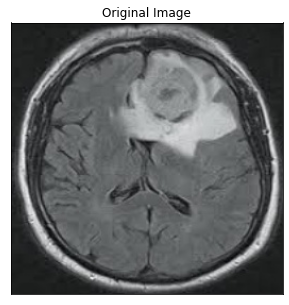

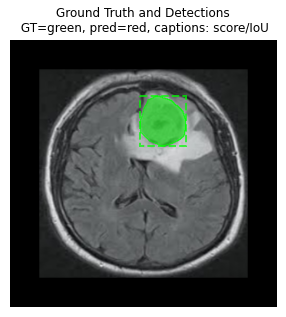

In [20]:
print("Sample 1")
ind = 10
display_image(dataset_val, ind)
predict_and_plot_differences(dataset_val, ind)


Sample 2


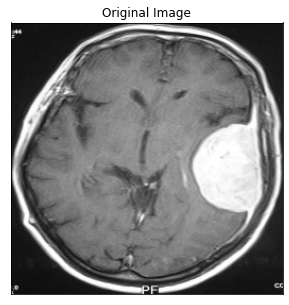

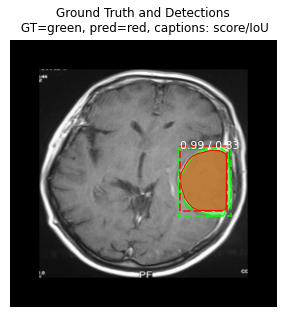

In [21]:
print("Sample 2")
ind = 16
display_image(dataset_val, ind)
predict_and_plot_differences(dataset_val, ind)

Sample 3


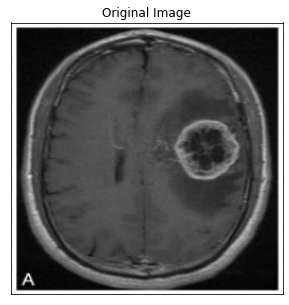

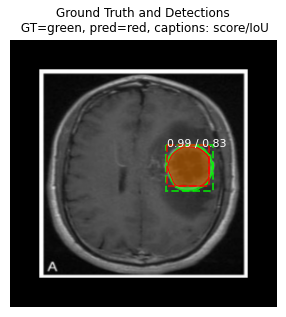

In [22]:
print("Sample 3")
ind = 0
display_image(dataset_test, ind)
predict_and_plot_differences(dataset_test, ind)

Sample 4


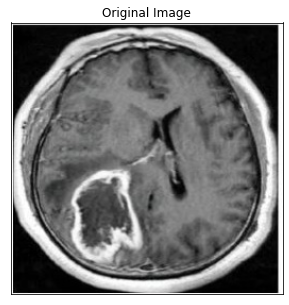

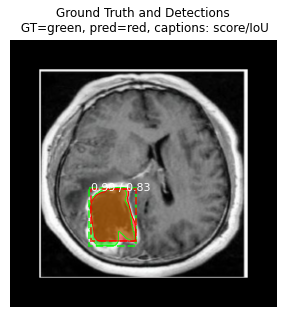

In [23]:
print("Sample 4")
ind = 2
display_image(dataset_test, ind)
predict_and_plot_differences(dataset_test, ind)

Sample 5


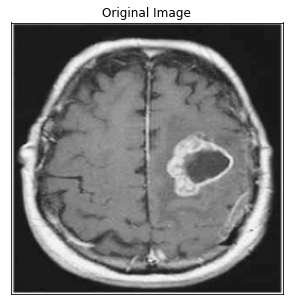

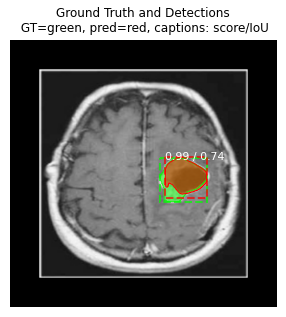

In [24]:
print("Sample 5")
ind = 3
display_image(dataset_test, ind)
predict_and_plot_differences(dataset_test, ind)

# 12- References
1. https://www.kaggle.com/ruslankl/brain-tumor-detection-v2-0-mask-r-cnn
